*Name* : - **Arya Joshi** 

*Roll No.* : - **23B1853**

Acknowledgement :- ChatGPT was used to assist in making this journal report

# **Time Resolved Absorption Spectroscopy**

# Aim

# Apparatus  

## Observations

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

     Laser Delay [ns]  TA [mOD]
0                -400  0.096762
1                -390 -0.202048
2                -380  0.089099
3                -370 -0.156065
4                -360 -0.274076
..                ...       ...
536              4960  0.568701
537              4970  0.055678
538              4980 -0.063692
539              4990  0.015642
540              5000  0.050880

[541 rows x 2 columns]


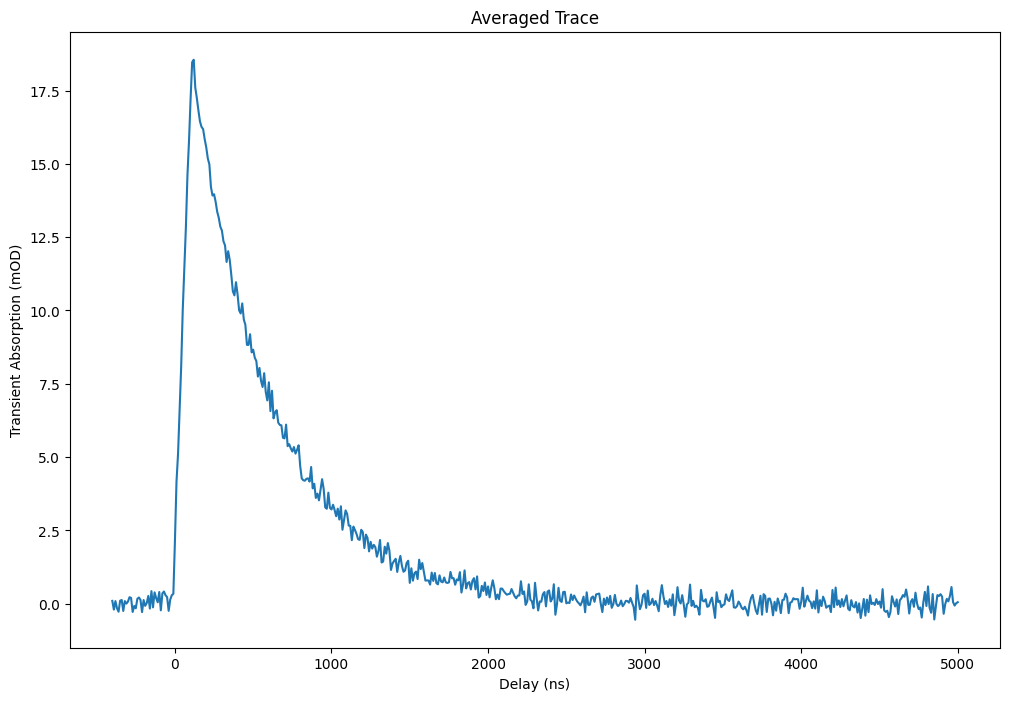

In [10]:
Avg_trace = pd.read_csv('Plots - 5.csv')

print(Avg_trace)
plt.figure(figsize=(12, 8))
plt.plot(Avg_trace['Laser Delay [ns]'], Avg_trace['TA [mOD]'], label='Main Trace')
plt.xlabel('Delay (ns)')
plt.ylabel('Transient Absorption (mOD)')
plt.title('Averaged Trace')
plt.show()

     Laser Delay [ns]  TA1 [mOD]  TA2 [mOD]  TA3 [mOD]  TA4 [mOD]  TA5 [mOD]
0                -400  -0.109308  -0.121159  -0.007047   0.587693   0.133633
1                -390   0.123624   0.831097  -0.792537  -0.457132  -0.715292
2                -380   0.206026  -0.956995   0.235134   1.195799  -0.234468
3                -370   0.208361  -0.016481  -0.270023  -0.514529  -0.187652
4                -360  -0.130666  -0.583700  -0.620672   0.228450  -0.263793
..                ...        ...        ...        ...        ...        ...
536              4960   0.718330   0.089319   1.015461   0.858665   0.161731
537              4970   0.237922   0.997892  -0.610610   0.294309  -0.641121
538              4980  -0.318023  -0.028184  -0.692410   0.536170   0.183988
539              4990  -0.260189   0.595479   0.095041  -0.893821   0.541701
540              5000   0.165976  -0.045819   0.404956   0.039860  -0.310572

[541 rows x 6 columns]


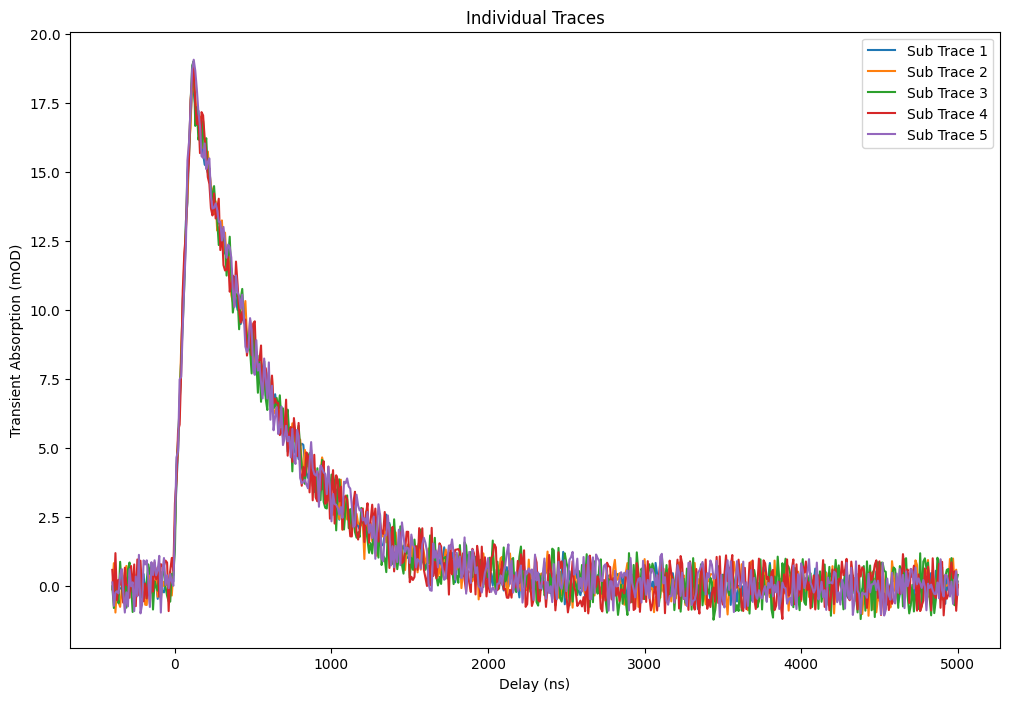

In [11]:
Sub_traces = pd.read_csv('Plots - 5_traces.csv')

print(Sub_traces)
plt.figure(figsize=(12, 8))
plt.plot(Sub_traces['Laser Delay [ns]'], Sub_traces['TA1 [mOD]'], label='Sub Trace 1')
plt.plot(Sub_traces['Laser Delay [ns]'], Sub_traces['TA2 [mOD]'], label='Sub Trace 2')
plt.plot(Sub_traces['Laser Delay [ns]'], Sub_traces['TA3 [mOD]'], label='Sub Trace 3')
plt.plot(Sub_traces['Laser Delay [ns]'], Sub_traces['TA4 [mOD]'], label='Sub Trace 4')
plt.plot(Sub_traces['Laser Delay [ns]'], Sub_traces['TA5 [mOD]'], label='Sub Trace 5')
plt.xlabel('Delay (ns)')
plt.ylabel('Transient Absorption (mOD)')
plt.title('Individual Traces')
plt.legend()
plt.show()

## Calculations

Maximum Transient Absorption: 18.552764 mOD
At Laser Delay: 120.0 ns


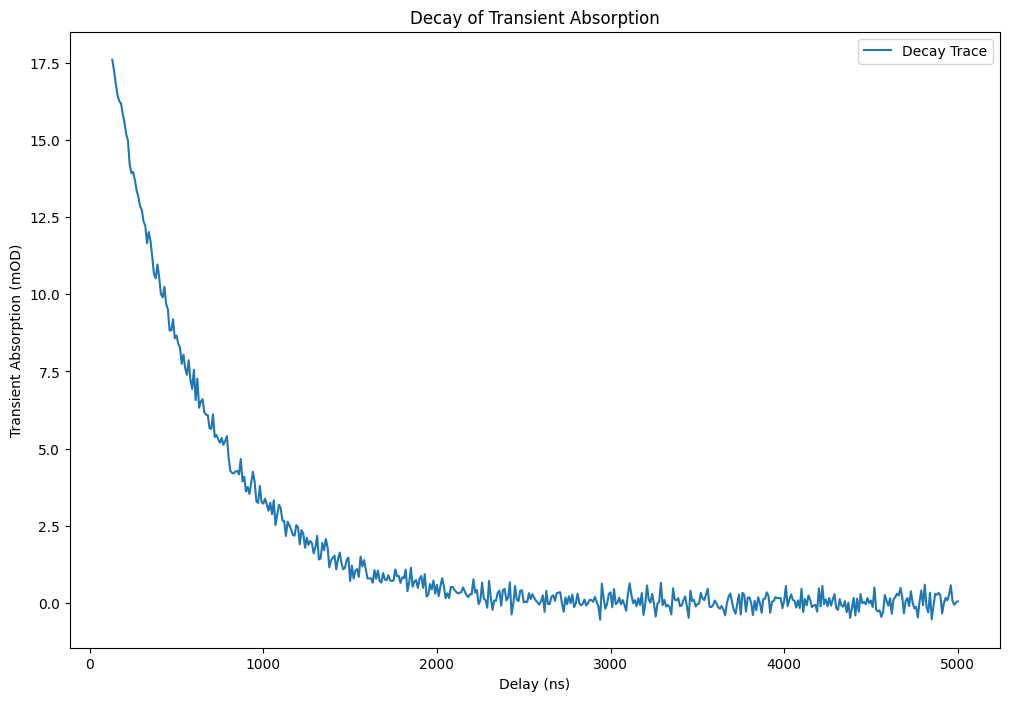

In [16]:
Maxima = Avg_trace.iloc[np.argmax(Avg_trace['TA [mOD]'])]
print(f'Maximum Transient Absorption: {Maxima["TA [mOD]"]} mOD')
print(f'At Laser Delay: {Maxima["Laser Delay [ns]"]} ns')


Decay_Trace = Avg_trace[Avg_trace['Laser Delay [ns]'] > Maxima['Laser Delay [ns]']]
plt.figure(figsize=(12, 8))
plt.plot(Decay_Trace['Laser Delay [ns]'], Decay_Trace['TA [mOD]'], label='Decay Trace')
plt.xlabel('Delay (ns)')    
plt.ylabel('Transient Absorption (mOD)')
plt.title('Decay of Transient Absorption')  
plt.legend()
plt.show()

Fitted parameters: a = 22.64306, b = 0.00194
  R² = 0.995790


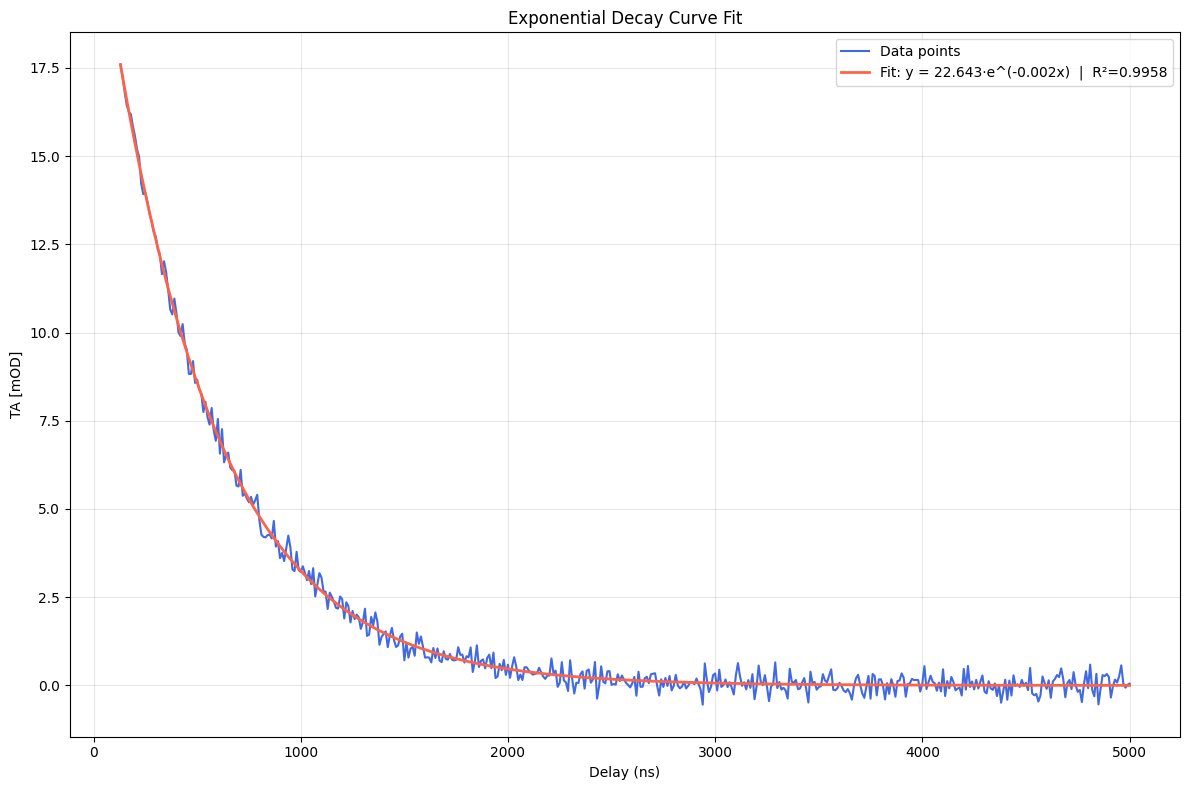

In [28]:
# Fitting an exponential decay to the decay trace
from scipy.optimize import curve_fit

def exp_decay(x, a, b):
    return a * np.exp(-b * x)

# --- Fit ---
p0 = [max(Decay_Trace['TA [mOD]']), 0]  # initial guesses: a ~ max(y), b ~ 0.5
params, covariance = curve_fit(exp_decay, Decay_Trace['Laser Delay [ns]'], Decay_Trace['TA [mOD]'], p0=p0)
a_fit, b_fit = params

print(f'Fitted parameters: a = {a_fit:.5f}, b = {b_fit:.5f}')

y_pred = exp_decay(Decay_Trace['Laser Delay [ns]'], *params)
ss_res = np.sum((Decay_Trace['TA [mOD]'] - y_pred) ** 2)
ss_tot = np.sum((Decay_Trace['TA [mOD]'] - np.mean(Decay_Trace['TA [mOD]'])) ** 2)
r_squared = 1 - ss_res / ss_tot
print(f"  R² = {r_squared:.6f}")

# --- Plot ---
x_smooth = np.linspace(Decay_Trace['Laser Delay [ns]'].min(), Decay_Trace['Laser Delay [ns]'].max(), 300)
y_smooth = exp_decay(x_smooth, *params)

plt.figure(figsize=(12, 8))
plt.plot(Decay_Trace['Laser Delay [ns]'], Decay_Trace['TA [mOD]'], color='royalblue', label='Data points')
plt.plot(x_smooth, y_smooth, color='tomato', linewidth=2,
         label=f'Fit: y = {a_fit:.3f}·e^(-{b_fit:.3f}x)  |  R²={r_squared:.4f}')
plt.xlabel('Delay (ns)')
plt.ylabel('TA [mOD]')
plt.title('Exponential Decay Curve Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
Relaxation_Time = 1 / b_fit
print(f'Relaxation Time (τ): {Relaxation_Time:.5f} ns')

Relaxation Time (τ): 514.91603 ns


## Results

In [30]:
print("The relaxation time of the sample ZnTPP is: {:.5f} ns".format(Relaxation_Time))

The relaxation time of the sample ZnTPP is: 514.91603 ns
